# 🌍 Tutorial 3: Group-Level Interpretation via Sensor-Space Matching

Welcome to the third and final tutorial for **HeteroRC**!

In Tutorial 2, we successfully opened the "black box" of HeteroRC for a single individual, revealing the temporal, spectral, and spatial motifs driving their decoding performance. However, in cognitive neuroscience, we typically want to draw conclusions at the **Group Level** (Grand-Average) across a cohort of participants.

**The Challenge**: 
Reservoir Computing relies on randomly initialized recurrent networks. This means the latent state space is highly idiosyncratic to each participant. "Unit 42" in Subject 1's reservoir has absolutely no correspondence to "Unit 42" in Subject 2's reservoir.

**The HeteroRC Solution (Sensor-Space Matching)**:
To overcome this, HeteroRC employs a novel "sensor-space matching" approach.
1. **Extraction**: We extract the top $N$ most informative units from *each* participant.
2. **Projection**: We project their latent activities out of the idiosyncratic reservoir and into the common, physical EEG sensor space (Topomaps).
3. **Sign-Alignment**: Because units can have arbitrary polarities (a positive weight $\times$ positive activity equals a negative weight $\times$ negative activity), we align their spatial polarities to prevent signal cancellation when averaging.
4. **Global Clustering**: We pool these standardized topographies across all participants and cluster them to identify consistent, population-level neural motifs!

In this tutorial, for computational efficiency, we will demonstrate this pipeline using the first **3 Subjects** from the BCI Competition IV-2a dataset.

In [ ]:
import os

## --- Prevent Jupyter Kernel Crashes, if needed ---
## Limit multi-threading for underlying matrix libraries (OpenBLAS/MKL)
#os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["MKL_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
#os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import mne
import scipy.io
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV

# Import HeteroRC modules
from heterorc import HeteroRC, time_resolved_decoding_heterorc
from heterorc_interpretation import analyze_dynamics_group

# --- USER CONFIGURATION ---
DATA_DIR = r"./BCI2a/Data"  # Update to your local path
SUBJECTS = [1, 2, 3]        # We will use the first 3 subjects for this tutorial demo

SFREQ = 100.0  
N_RESERVOIR = 400  
N_FOLDS = 5

rc_params = dict(
    n_res=N_RESERVOIR, input_scaling=0.5, bias_scaling=0.5, spectral_radius=0.95,
    tau_mode=0.01, tau_sigma=0.8, tau_min=0.002, tau_max=0.08,
    bidirectional=True, merge_mode="product",
)

bci2a_class_names = ["Left Hand", "Right Hand", "Foot", "Tongue"]

## Step 1: Subject-Level Feature Extraction Loop

Before we can perform group-level matching, we must first process each subject individually. For every subject in our list, we will:
1. Load their Train and Test EEG data.
2. Run a strict Cross-Validation on the Training set to find their individual **Peak Decoding Time** during the Imagination phase.
3. Concatenate the Train and Test sets, and project the full dataset into their uniquely initialized reservoir.
4. Fit a linear readout exactly at their peak time.
5. Pack all of these objects (raw data, states, classifier, labels) into a dictionary.

We will collect these dictionaries into a master list called `subject_data_list`.

In [2]:
# Simplified data loader (reused from Tutorial 2)
def load_bci2a_subject(sub_id, data_dir, sfreq=100.0):
    bci2a_channels = ["Fz", "FC3", "FC1", "FCz", "FC2", "FC4", "C5", "C3", "C1", "Cz", "C2", 
                      "C4", "C6", "CP3", "CP1", "CPz", "CP2", "CP4", "P1", "Pz", "P2", "POz"]
    def process_run(fname, is_test=False):
        raw = mne.io.read_raw_gdf(os.path.join(data_dir, fname), preload=True, verbose=False)
        raw.rename_channels(dict(zip(raw.ch_names[:22], bci2a_channels)))
        for ch in raw.ch_names[22:]: raw.set_channel_types({ch: "eog"})
        raw.set_montage(mne.channels.make_standard_montage("standard_1020"))
        raw.filter(0.5, 30.0, fir_design="firwin", verbose=False)
        raw.resample(sfreq, npad="auto", verbose=False)
        raw.set_eeg_reference("average", projection=False, verbose=False)
        
        event_id = {"783": 100} if is_test and "783" in raw.annotations.description else {"769": 1, "770": 2, "771": 3, "772": 4}
        events, _ = mne.events_from_annotations(raw, event_id=event_id, verbose=False)
        
        if is_test and "783" not in raw.annotations.description:
            events_start, _ = mne.events_from_annotations(raw, event_id={"768": 100}, verbose=False)
            events = events_start.copy()
            events[:, 0] += int(2.0 * sfreq)
        if is_test and len(events) > 288: events = events[-288:]
        epochs = mne.Epochs(raw, events, tmin=-0.2, tmax=3.2, picks="eeg", baseline=(-0.2, 0), preload=True, verbose=False)
        return epochs

    ep_train = process_run(f"A0{sub_id}T.gdf", is_test=False)
    X_train, y_train = ep_train.get_data(copy=True) * 1e6, ep_train.events[:, -1]
    
    ep_test = process_run(f"A0{sub_id}E.gdf", is_test=True)
    mat = scipy.io.loadmat(os.path.join(data_dir, f"A0{sub_id}E.mat"))
    y_test = np.concatenate([
        mat["data"][0][i]["y"][0, 0].flatten() if "y" in mat["data"][0][i].dtype.names else mat["data"][0][i]["classlabel"][0, 0].flatten()
        for i in range(3, 9)
    ])
    X_test = ep_test.get_data(copy=True) * 1e6
    return X_train, y_train, X_test, y_test, ep_train.times, ep_train.info

# --- Execution Loop ---
subject_data_list = []
global_info = None
sigma_points = (25.0 / 1000.0 * SFREQ) / 2.355

print(f"Starting Subject-Level Feature Extraction for {len(SUBJECTS)} subjects...")

for sub_id in SUBJECTS:
    print(f"\nProcessing Subject 0{sub_id}...")
    X_train, y_train, X_test, y_test, times, info = load_bci2a_subject(sub_id, DATA_DIR, SFREQ)
    if global_info is None: global_info = info
        
    # 1. Strict Peak Search (Train CV)
    cv_curve = time_resolved_decoding_heterorc(
        X=X_train, y=y_train, times=times, n_folds=N_FOLDS, fs=SFREQ,
        rc_params=rc_params, scale_percentile=99, rc_seed_mode="fixed",
        base_rc_random_state=42, metric="accuracy", smooth_decisions=True,
        smooth_sigma_points=sigma_points, verbose=False
    )
    
    # Restrict search to the Imagination window (1.25s - 3.0s)
    imagination_mask = (times >= 1.25) & (times <= 3.0)
    window_indices = np.where(imagination_mask)[0]
    peak_offset = int(np.argmax(cv_curve[window_indices]))
    peak_idx = int(window_indices[peak_offset])
    peak_time = float(times[peak_idx])
    
    print(f"  -> Peak decoding found at: {peak_time:.3f} s")

    # 2. Build Full Dataset
    X_full = np.concatenate([X_train, X_test], axis=0)
    y_full = np.concatenate([y_train, y_test], axis=0)
    scale_val = np.percentile(np.abs(X_full), 99)
    X_full_s = X_full / scale_val

    # 3. Project to Reservoir
    esn = HeteroRC(n_in=X_full.shape[1], random_state=42, fs=SFREQ, **rc_params)
    S_full = esn.transform(X_full_s)

    # 4. Fit Readout exactly at Peak Time
    clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=(0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0)))
    clf.fit(S_full[:, :, peak_idx], y_full)

    # 5. Pack data
    subject_data_list.append({
        'X': X_full,
        'S': S_full,
        'y': y_full,
        'times': times,
        'target_time': peak_time,
        'classifier': clf,
        'esn': esn
    })

print("\n✅ All subjects processed and packed!")

Starting Subject-Level Feature Extraction for 3 subjects...

Processing Subject 01...


D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Peak decoding found at: 1.700 s

Processing Subject 02...


D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Peak decoding found at: 1.520 s

Processing Subject 03...


D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  -> Peak decoding found at: 1.600 s

✅ All subjects processed and packed!


## Step 2: Global Spatial Clustering & Reconstruction

Now we pass our `subject_data_list` into `analyze_dynamics_group`. 

Under the hood, this function:
1. Computes the **Haufe transform** for each participant's classifier to find their top $N$ units (here, `top_n=10`).
2. Computes the sensor-space covariance map for each unit and performs **Sign-Alignment**.
3. Pools the 30 standardized topographies (3 subjects $\times$ 10 units) and clusters them into `n_clusters=3` global spatial motifs using Ward's linkage.
4. Maps these global clusters back to the individuals to reconstruct and average their virtual source signals.

Let's run it and visualize the Grand-Average dynamics!

Executing Group-Level Interpretation via Sensor-Space Matching...

Running GROUP-LEVEL INTERPRETATION | BCI2a Group Average (N=3) - Imagination Phase | Top 10 Units
-> Phase 1: Extracting Top 10 units & Spatial Sign-Alignment...


C:\Users\Lenovo\Documents\GitHub\heterorc\heterorc_interpretation.py:838: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


-> Phase 2: Global Hierarchical Clustering (N=3)...
-> Phase 3: Reconstructing Grand Average Dynamics...


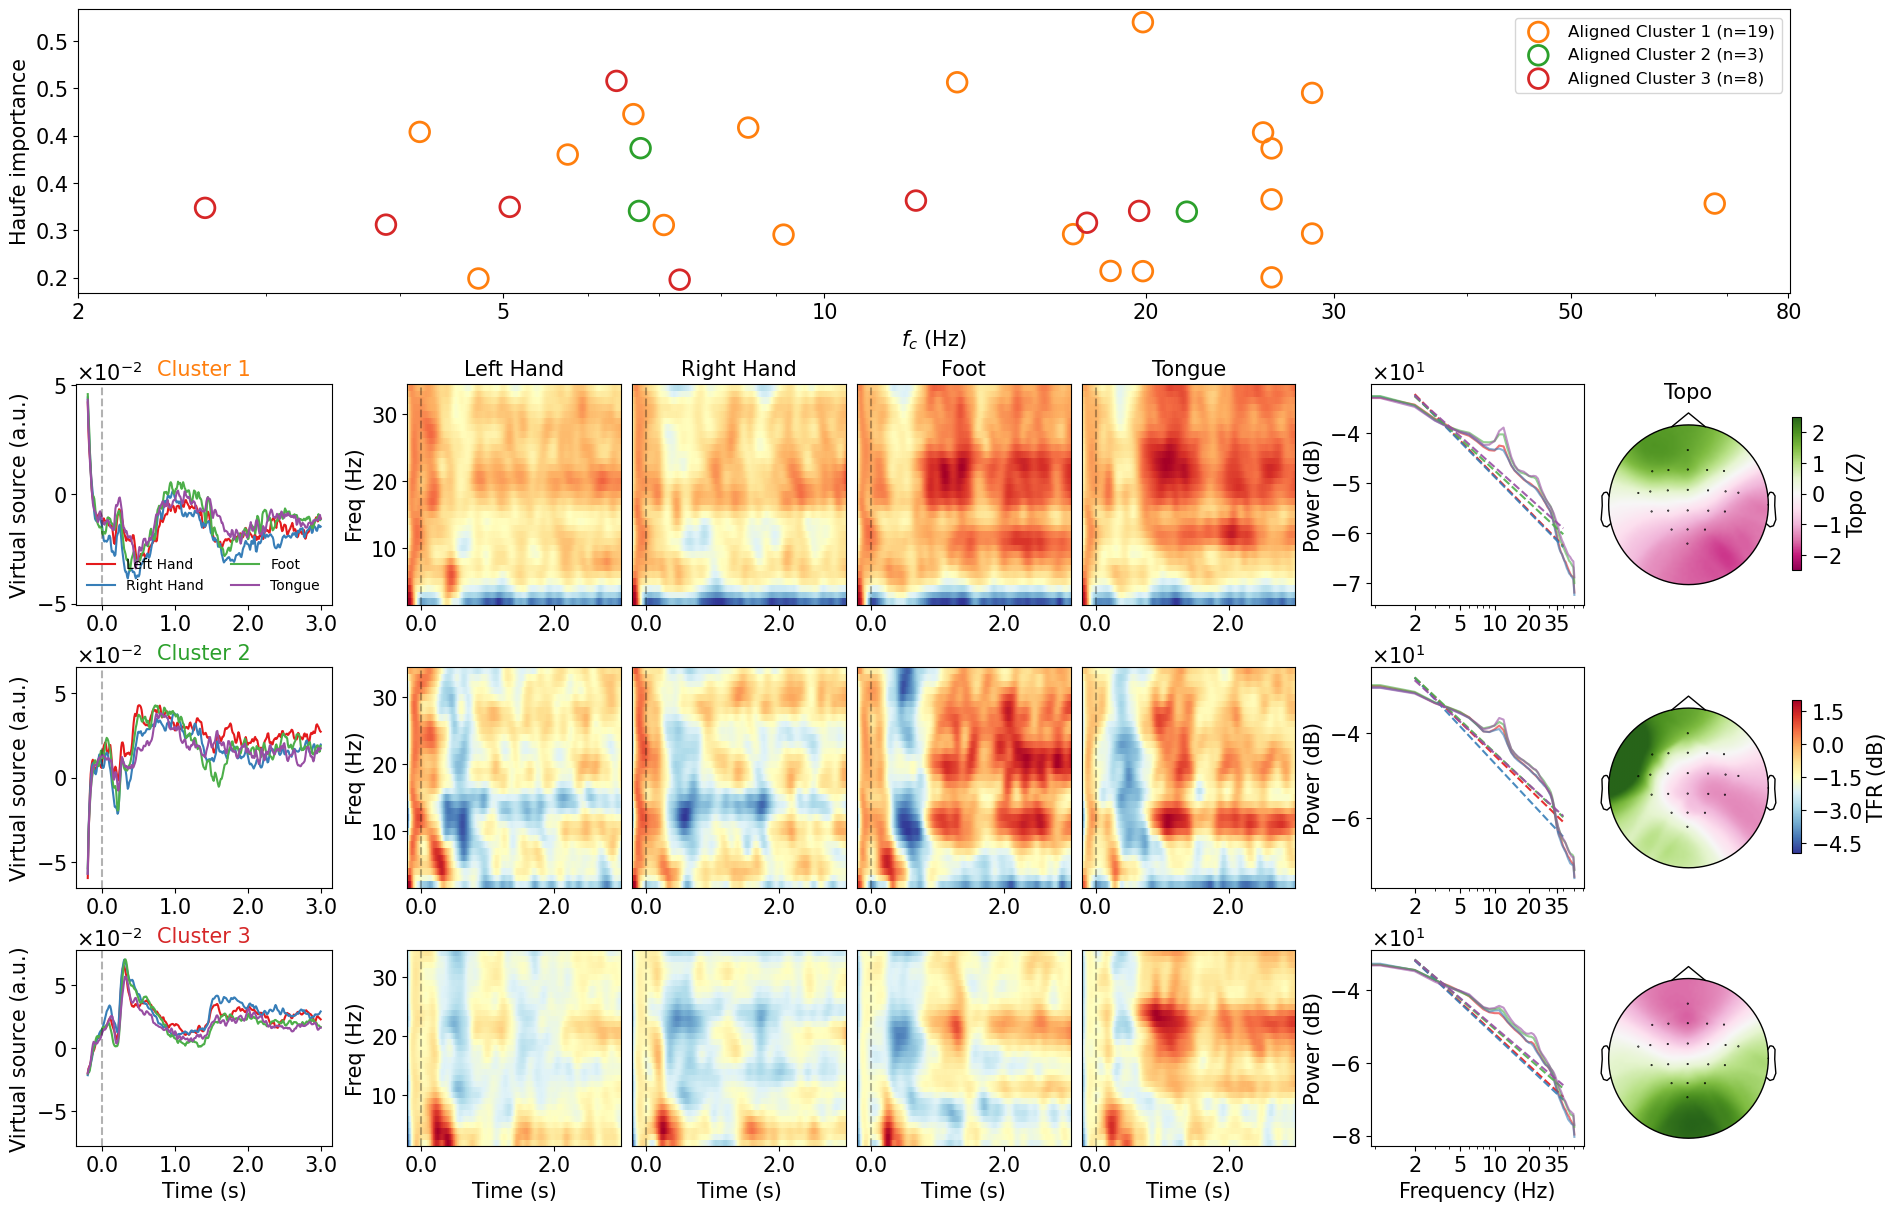

In [3]:
print("Executing Group-Level Interpretation via Sensor-Space Matching...")

group_results = analyze_dynamics_group(
    subject_data_list=subject_data_list,
    info=global_info,
    n_clusters=3,
    top_n=10,                      
    phase_name=f"BCI2a Group Average (N={len(SUBJECTS)}) - Imagination Phase",
    
    # ERP settings
    erp_range=(-0.2, 3.0),
    erp_baseline_mode="mean",
    erp_baseline_range=(-0.2, 0),
    
    # TFR settings
    tfr_baseline_mode="logratio",
    tfr_baseline_range=(-0.2, 0.0),
    tfr_freqs=np.arange(2, 35, 1),
    
    # FOOOF settings
    fooof_params={"max_n_peaks": 4, "peak_width_limits": [1, 8]},
    
    # Visual settings
    plot_style="poster",
    figsize=(18, 12),
    class_names=bci2a_class_names,
    cov_window_half_width=0.1,
    
    # Workspace export
    return_results=True,
    export_virtual_sources=True   # We set this to True to get subject-specific data back!
)

## Step 3: Extracting Data for Cross-Subject Statistics & Visualization

The `analyze_dynamics_group` function is designed not just to plot figures, but to return the raw underlying data for downstream statistical analyses (e.g., cluster-based permutation tests across subjects). 

Because we set `export_virtual_sources=True`, the returned `group_results` dictionary contains:
1. **Grand-Average Signals**: The pooled `ga_erps`, `ga_tfrs`, and `ga_psds` across all subjects.
2. **Individual-Level Assignments**: For each global cluster, we get the exact reservoir unit indices (`subject_unit_indices`) and their spatial polarities (`subject_sign_flips`) for every participant.

Let's demonstrate this by extracting the data for **ALL Global Clusters** during the "Left Hand" imagery condition. We will loop through the clusters and plot a 3-row figure:
* **Left Column**: The raw, sign-aligned temporal dynamics of the specific reservoir units from a selected individual (e.g., **Subject 1**) that were mapped to each Global Cluster.
* **Right Column**: The final **Grand-Average Virtual Source (ERP)** for each Global Cluster, averaged across all 3 subjects.

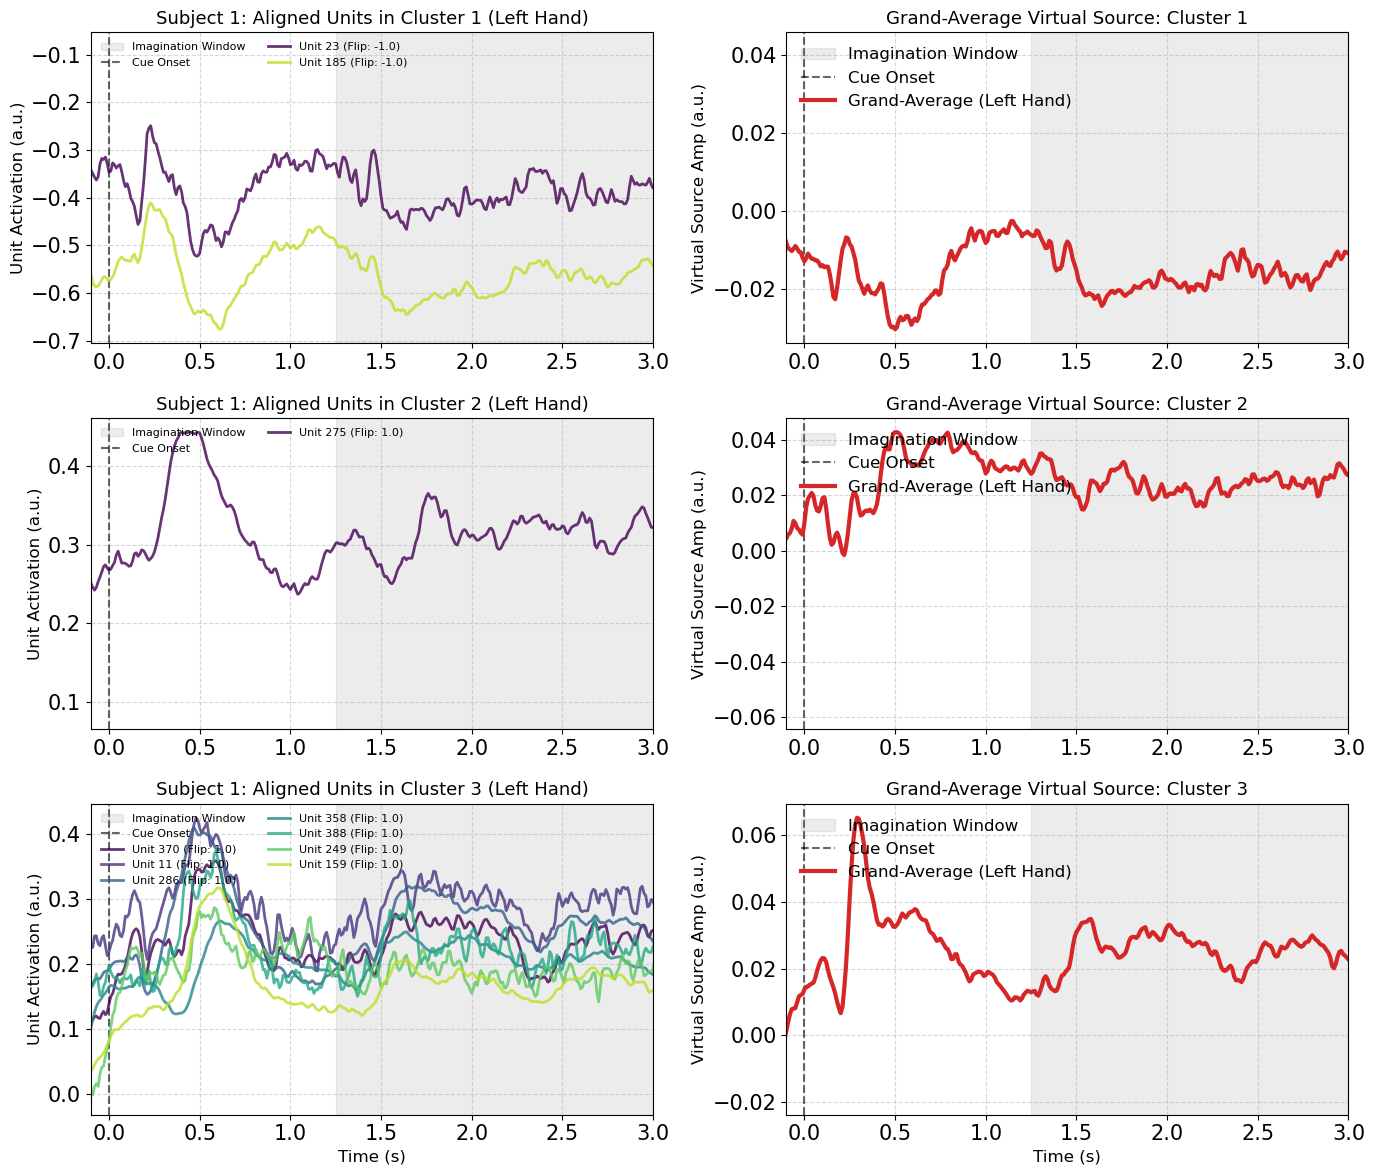

In [12]:
# 1. Extract metadata and identify the target class (e.g., Class 1: "Left Hand")
target_class = group_results["meta"]["classes"][0]
class_name = group_results["meta"]["class_names"][0]
times = group_results["meta"]["times"]

# We need a matching time vector for the Grand-Average ERPs (-0.2s to 3.0s)
mask_plot_erp = (times >= -0.2) & (times <= 3.0)
times_plot = times[mask_plot_erp]

clusters_dict = group_results["clusters"]
cluster_names = list(clusters_dict.keys())  # e.g., ['Cluster 1', 'Cluster 2', 'Cluster 3']

# 2. Select the subject to display in the left panel 
# (Index 0 = Sub 1, Index 1 = Sub 2, Index 2 = Sub 3)
target_sub_idx = 0  
actual_sub_id = SUBJECTS[target_sub_idx]

S_target_sub = subject_data_list[target_sub_idx]['S']
y_target_sub = subject_data_list[target_sub_idx]['y']

# 3. Setup the figure (N_clusters Rows x 2 Columns)
fig, axes = plt.subplots(len(cluster_names), 2, figsize=(14, 4 * len(cluster_names)))

for row_idx, c_name in enumerate(cluster_names):
    cluster_data = clusters_dict[c_name]
    
    # =========================================================================
    # Panel A (Left): Selected Subject's Aligned Units
    # =========================================================================
    ax_left = axes[row_idx, 0]
    ax_left.axvspan(1.25, 3.0, color="gray", alpha=0.15, label="Imagination Window")
    ax_left.axvline(0, color="black", linestyle="--", alpha=0.6, label="Cue Onset")
    
    sub_unit_indices = cluster_data["subject_unit_indices"][target_sub_idx]
    sub_sign_flips = cluster_data["subject_sign_flips"][target_sub_idx]
    
    if sub_unit_indices is not None and len(sub_unit_indices) > 0:
        colors = plt.cm.viridis(np.linspace(0, 0.9, len(sub_unit_indices)))
        
        for i, (unit, s_flip) in enumerate(zip(sub_unit_indices, sub_sign_flips)):
            # Extract unit activity for the target class and average across trials
            unit_activity = S_target_sub[y_target_sub == target_class, unit, :].mean(axis=0)
            
            # CRITICAL: Apply the sign-flip so the polarities match the global spatial motif
            aligned_activity = unit_activity * s_flip
            
            ax_left.plot(times, aligned_activity, color=colors[i], linewidth=2, alpha=0.8,
                         label=f"Unit {unit} (Flip: {s_flip})")
    else:
        ax_left.text(0.5, 0.5, f"No units assigned to this cluster for Sub {actual_sub_id}", 
                     ha='center', va='center', transform=ax_left.transAxes, fontsize=12)

    ax_left.set_title(f"Subject {actual_sub_id}: Aligned Units in {c_name} ({class_name})", fontsize=13)
    ax_left.set_ylabel("Unit Activation (a.u.)", fontsize=12)
    ax_left.legend(loc="upper left", frameon=False, fontsize=8, ncol=2)
    ax_left.grid(True, linestyle="--", alpha=0.5)
    ax_left.set_xlim(-0.1, 3.0)  # Focus the x-axis
    
    if row_idx == len(cluster_names) - 1:
        ax_left.set_xlabel("Time (s)", fontsize=12)

    # =========================================================================
    # Panel B (Right): Grand-Average ERP across all subjects
    # =========================================================================
    ax_right = axes[row_idx, 1]
    ax_right.axvspan(1.25, 3.0, color="gray", alpha=0.15, label="Imagination Window")
    ax_right.axvline(0, color="black", linestyle="--", alpha=0.6, label="Cue Onset")
    
    # ga_erps is a list of subject-averaged ERPs. Take the mean across subjects (axis=0).
    ga_erp_class = np.mean(cluster_data["ga_erps"][target_class], axis=0)
    
    ax_right.plot(times_plot, ga_erp_class, color="#d62728", linewidth=3, label=f"Grand-Average ({class_name})")

    ax_right.set_title(f"Grand-Average Virtual Source: {c_name}", fontsize=13)
    ax_right.set_ylabel("Virtual Source Amp (a.u.)", fontsize=12)
    ax_right.legend(loc="upper left", frameon=False)
    ax_right.grid(True, linestyle="--", alpha=0.5)
    ax_right.set_xlim(-0.1, 3.0)  # Focus the x-axis
    
    if row_idx == len(cluster_names) - 1:
        ax_right.set_xlabel("Time (s)", fontsize=12)

plt.tight_layout()
plt.show()